In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

# Gör simuleringar repeterbara
np.random.seed(42)

# Läs in data 
df = pd.read_csv("data/health_study_dataset.csv")

df.head()


,id,age,sex,height,weight,systolic_bp,cholesterol,smoker,disease
0,1,57,F,168.9,65.8,141.8,4.58,No,0
1,2,47,M,180.4,95.9,144.8,5.18,Yes,0
2,3,59,F,169.9,82.2,151.7,6.16,No,0
3,4,72,M,157.7,93.1,151.0,6.63,No,0
4,5,46,M,192.6,104.1,144.1,5.21,No,0


## Beskrivande statistik 


In [28]:
cols = ["age", "weight", "height", "systolic_bp", "cholesterol"]

# Skriv ut medel, median, min, max för varje kolumn
for c in cols:
    mean_v = df[c].mean()
    med_v = df[c].median()
    min_v = df[c].min()
    max_v = df[c].max()
    print(f"{c}: medel={mean_v:.2f}, median={med_v:.2f}, min={min_v:.2f}, max={max_v:.2f}")


age: medel=49.43, median=50.00, min=18.00, max=90.00
weight: medel=73.41, median=73.20, min=33.70, max=114.40
height: medel=171.85, median=171.35, min=144.40, max=200.40
systolic_bp: medel=149.18, median=149.40, min=106.80, max=185.90
cholesterol: medel=4.93, median=4.97, min=2.50, max=7.88


## Några snabba grafer
Histogram, boxplot och stapel för rökning.


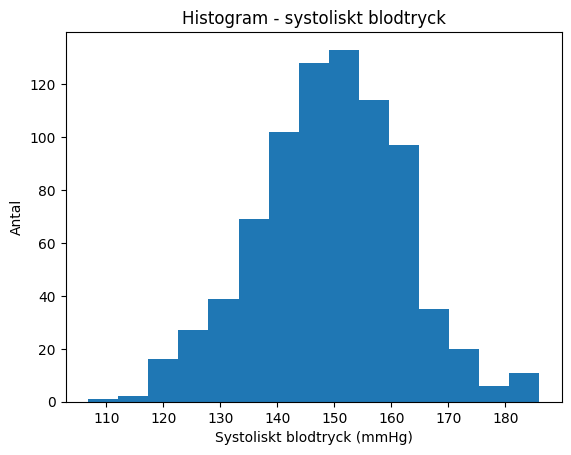

<Figure size 640x480 with 0 Axes>

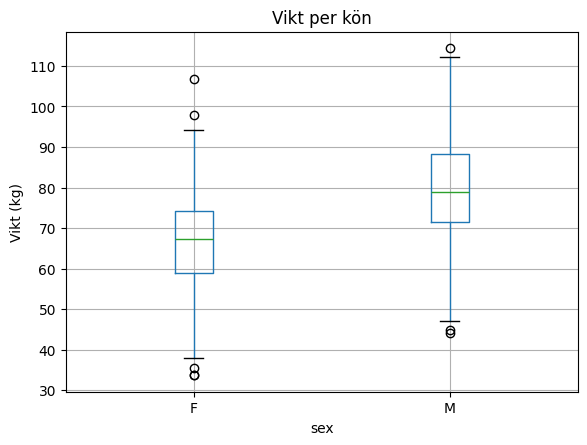

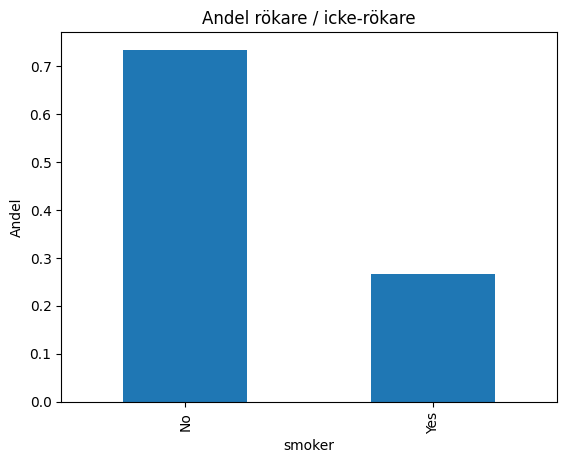

In [29]:
# Histogram systoliskt blodtryck
plt.figure()
plt.hist(df["systolic_bp"].dropna(), bins=15)
plt.xlabel("Systoliskt blodtryck (mmHg)")
plt.ylabel("Antal")
plt.title("Histogram - systoliskt blodtryck")
plt.show()

# Boxplot vikt per kön 
plt.figure()
df.boxplot(column="weight", by="sex")
plt.suptitle("")  # ta bort dubbletterna
plt.ylabel("Vikt (kg)")
plt.title("Vikt per kön")
plt.show()

# Stapel - andel rökare
sm = df["smoker"].value_counts(normalize=True)
plt.figure()
sm.plot(kind="bar")
plt.ylabel("Andel")
plt.title("Andel rökare / icke-rökare")
plt.show()


## Simulering: sjukdomsförekomst
Räkna andel i data och simulera 1000 personer med samma sannolikhet.


In [30]:
real_rate = df["disease"].mean()
print(f"Verklig andel med sjukdom: {real_rate:.3f}")

n_sim = 1000
sim = np.random.binomial(1, real_rate, size=n_sim)
sim_rate = sim.mean()
print(f"Simulerad andel (1000 personer): {sim_rate:.3f}")


Verklig andel med sjukdom: 0.059
Simulerad andel (1000 personer): 0.056


## Konfidensintervall för medelvärdet (systolic_bp) normalapproximation


In [31]:
bp = df["systolic_bp"].dropna()
n = len(bp)
mean_bp = bp.mean()
std_bp = bp.std(ddof=1)
se = std_bp / np.sqrt(n)
z = 1.96  # 95 % CI

ci_low = mean_bp - z*se
ci_high = mean_bp + z*se

print(f"Medel: {mean_bp:.2f}")
print(f"95% CI (normal): [{ci_low:.2f}, {ci_high:.2f}]")


Medel: 149.18
95% CI (normal): [148.29, 150.07]


## Bootstrap (95% CI) 


In [32]:
boot_means = []
B = 2000  # håller nere så det går snabbt
for i in range(B):
    s = bp.sample(frac=1, replace=True)
    boot_means.append(s.mean())

boot_low = np.percentile(boot_means, 2.5)
boot_high = np.percentile(boot_means, 97.5)
print(f"95% CI (bootstrap): [{boot_low:.2f}, {boot_high:.2f}]")


95% CI (bootstrap): [148.33, 150.09]


## Hypotes: Rökare har högre medel blodtryck än icke rökare
Jag kör ett enkelt permutationstest: blanda grupperna många gånger och se hur ofta skillnaden är lika stor.


In [33]:
smokers = df[df["smoker"] == "Yes"]["systolic_bp"].dropna().values
nonsmokers = df[df["smoker"] == "No"]["systolic_bp"].dropna().values

obs_diff = smokers.mean() - nonsmokers.mean()
print(f"Observerad skillnad (smokers - nonsmokers): {obs_diff:.2f}")

combined = np.concatenate([smokers, nonsmokers])
n_sm = len(smokers)
R = 2000
count = 0
for i in range(R):
    np.random.shuffle(combined)
    a = combined[:n_sm]
    b = combined[n_sm:]
    d = a.mean() - b.mean()
    if d >= obs_diff:
        count += 1

pval = count / R
print(f"Ungefärligt p-värde (ensidigt): {pval:.3f}")


Observerad skillnad (smokers - nonsmokers): 0.47
Ungefärligt p-värde (ensidigt): 0.328


Tolkning: Om p-värdet är > 0.05 kan vi inte med god säkerhet säga att rökare har högre blodtryck i denna data.


Jag har använt enkla metoder för att göra analysen lätt att förstå och följa:
- Beskrivande statistik för att se nivåer och spridning.
- Enkla grafer (histogram, boxplot, stapel) för visuella mönster.
- Simulering med `numpy.random` för att jämföra verklig andel och slump.
- Konfidensintervall både med normalapproximation och bootstrap.
- Permutationstest för hypotesprövning då det inte kräver starka antaganden.


